<a href="https://colab.research.google.com/github/vivekchavan2401/CSL701-CE04_Machine-Learning-Lab/blob/main/Copy_of_ML_Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :vivek vikas chavan

Batch :CE01


Roll Number :CE04




### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [1]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import networkx as nx

from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree, connected_components
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer Wisconsin (Diagnostic) dataset
data = load_breast_cancer(as_frame=True)

# Create a DataFrame with feature columns and target information
df = data.frame.copy()

# sklearn uses target 0 = malignant and 1 = benign
df["diagnosis"] = df["target"].map({0: "M", 1: "B"})

# Keep the 30 numerical predictor features
feature_columns = list(data.feature_names)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Number of samples:", len(df))
print("Number of numerical features:", len(feature_columns))
print("Feature names:")
print(feature_columns)
print("\nFirst 5 rows:")
display(df.head())


Dataset loaded successfully.
Shape: (569, 32)
Number of samples: 569
Number of numerical features: 30
Feature names:
[np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,M


# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

Missing values in each column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
diagnosis                  0
dtype: int64

Dataset dimensions:
Rows: 569
Columns: 32

Summary stati

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744



Diagnosis class distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Class distribution in percentage:
diagnosis
B    62.74
M    37.26
Name: count, dtype: float64


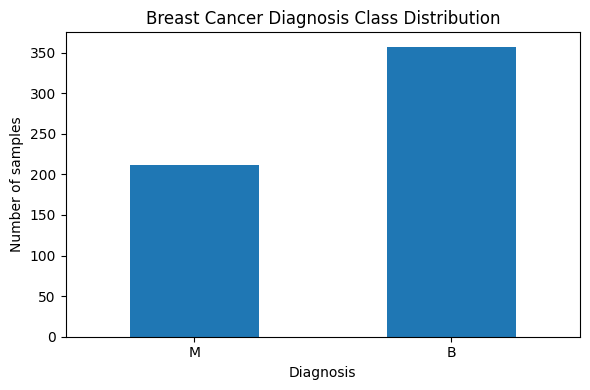

In [2]:
# Task 2: Explore the Dataset

print("Missing values in each column:")
print(df[feature_columns + ["diagnosis"]].isnull().sum())

print("\nDataset dimensions:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nSummary statistics:")
display(df[feature_columns].describe().T)

print("\nDiagnosis class distribution:")
class_counts = df["diagnosis"].value_counts()
print(class_counts)

print("\nClass distribution in percentage:")
print((class_counts / len(df) * 100).round(2))

# Optional visualization of class distribution
plt.figure(figsize=(6, 4))
class_counts.reindex(["M", "B"]).plot(kind="bar")
plt.xlabel("Diagnosis")
plt.ylabel("Number of samples")
plt.title("Breast Cancer Diagnosis Class Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [3]:
# Task 3: Preprocess and Scale Features

from sklearn.preprocessing import StandardScaler

# Select the 30 numerical features
X = df[feature_columns].copy()

# Ground-truth labels: M = malignant, B = benign
y = df["diagnosis"].copy()

# Standardize all numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data to a DataFrame for easy inspection
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=feature_columns,
    index=df.index
)

print("Original feature matrix shape:", X.shape)
print("Scaled feature matrix shape:", X_scaled.shape)

print("\nMean of scaled features (approximately 0):")
print(np.round(X_scaled.mean(axis=0), 6))

print("\nStandard deviation of scaled features (approximately 1):")
print(np.round(X_scaled.std(axis=0), 6))

display(X_scaled_df.head())


Original feature matrix shape: (569, 30)
Scaled feature matrix shape: (569, 30)

Mean of scaled features (approximately 0):
[-0.  0. -0. -0. -0.  0.  0. -0.  0.  0.  0. -0. -0. -0. -0.  0.  0.  0.
  0. -0. -0.  0. -0.  0. -0. -0.  0.  0.  0. -0.]

Standard deviation of scaled features (approximately 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [4]:
# Task 4: Construct Pairwise Distance Matrix & Graph

# Compute all pairwise Euclidean distances between standardized samples
distance_condensed = pdist(X_scaled, metric="euclidean")
distance_matrix = squareform(distance_condensed)

print("Pairwise distance matrix shape:", distance_matrix.shape)
print("Distance between sample 0 and sample 1:", distance_matrix[0, 1])

# Create the weighted complete graph.
# A complete graph has one edge between every pair of different samples.
G = nx.Graph()
G.add_nodes_from(range(X_scaled.shape[0]))

n_samples = X_scaled.shape[0]
for i in range(n_samples):
    for j in range(i + 1, n_samples):
        G.add_edge(i, j, weight=float(distance_matrix[i, j]))

print("\nComplete graph constructed successfully.")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Expected number of edges:", n_samples * (n_samples - 1) // 2)


Pairwise distance matrix shape: (569, 569)
Distance between sample 0 and sample 1: 10.318497148935617

Complete graph constructed successfully.
Number of nodes: 569
Number of edges: 161596
Expected number of edges: 161596


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [5]:
# Task 5: Compute the Minimum Spanning Tree (MST)

# Compute MST directly from the pairwise distance matrix.
mst_sparse = minimum_spanning_tree(distance_matrix)

# Convert the sparse MST to an undirected NetworkX graph
MST = nx.Graph()
MST.add_nodes_from(range(n_samples))

mst_rows, mst_cols = mst_sparse.nonzero()
mst_weights = np.asarray(mst_sparse[mst_rows, mst_cols]).ravel()

for u, v, w in zip(mst_rows, mst_cols, mst_weights):
    MST.add_edge(int(u), int(v), weight=float(w))

print("Minimum Spanning Tree computed successfully.")
print("Number of nodes:", MST.number_of_nodes())
print("Number of MST edges:", MST.number_of_edges())
print("Expected MST edges:", n_samples - 1)

# Extract and display MST connections and weights
mst_edges = sorted(
    [(u, v, data["weight"]) for u, v, data in MST.edges(data=True)],
    key=lambda x: x[2]
)

mst_edges_df = pd.DataFrame(
    mst_edges,
    columns=["Source", "Target", "Weight"]
)

print("\nFirst 10 MST edges:")
display(mst_edges_df.head(10))

print("Total MST weight:", round(mst_edges_df["Weight"].sum(), 4))


Minimum Spanning Tree computed successfully.
Number of nodes: 569
Number of MST edges: 568
Expected MST edges: 568

First 10 MST edges:


,Source,Target,Weight
0,79,362,1.006115
1,457,458,1.027614
2,271,390,1.097096
3,6,317,1.100976
4,90,545,1.120853
5,298,477,1.147710
6,74,137,1.148712
7,107,497,1.210592
8,425,522,1.216246
9,158,294,1.218008


Total MST weight: 1393.8521


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [6]:
# Task 6: Implement Graph-Based Clustering (K=2)

K = 2

# Sort MST edges in descending order of weight.
sorted_mst_edges = sorted(
    MST.edges(data=True),
    key=lambda e: e[2]["weight"],
    reverse=True
)

# For K=2, remove the single largest edge.
edges_to_remove = sorted_mst_edges[:K - 1]

# Create a copy of the MST and remove the largest edge.
MST_cluster = MST.copy()

for u, v, data in edges_to_remove:
    MST_cluster.remove_edge(u, v)

# Find connected components after removing the largest edge.
n_components, component_labels = connected_components(
    nx.to_scipy_sparse_array(MST_cluster, nodelist=range(n_samples), weight=None),
    directed=False,
    return_labels=True
)

# Store the final cluster labels
cluster_labels = component_labels

print("Requested number of clusters (K):", K)
print("Number of connected components obtained:", n_components)

print("\nRemoved MST edge(s):")
for u, v, data in edges_to_remove:
    print(f"({u}, {v}) -> weight = {data['weight']:.6f}")

print("\nCluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

# Add cluster labels to the original DataFrame
df["cluster"] = cluster_labels


Requested number of clusters (K): 2
Number of connected components obtained: 2

Removed MST edge(s):
(461, 503) -> weight = 12.299945

Cluster sizes:
0    567
1      2
Name: count, dtype: int64


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [7]:
# Task 7: Evaluate MST Clustering Performance

from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# Silhouette score uses the original pairwise distance matrix.
# It measures how well separated the generated clusters are.
silhouette = silhouette_score(
    distance_matrix,
    cluster_labels,
    metric="precomputed"
)

# Convert ground-truth diagnosis labels to numeric labels.
# The actual numeric values do not affect ARI/NMI.
y_true = y.map({"M": 0, "B": 1}).to_numpy()

ari = adjusted_rand_score(y_true, cluster_labels)
nmi = normalized_mutual_info_score(y_true, cluster_labels)

print("MST-Based Clustering Performance")
print("---------------------------------")
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

print("\nInterpretation:")
print("- Silhouette Score: higher values indicate better cluster separation.")
print("- ARI: 1.0 indicates perfect agreement with the ground truth; values near 0 indicate random agreement.")
print("- NMI: 1.0 indicates perfect agreement with the ground truth.")


MST-Based Clustering Performance
---------------------------------
Silhouette Score: 0.6607
Adjusted Rand Index (ARI): 0.0048
Normalized Mutual Information (NMI): 0.0102

Interpretation:
- Silhouette Score: higher values indicate better cluster separation.
- ARI: 1.0 indicates perfect agreement with the ground truth; values near 0 indicate random agreement.
- NMI: 1.0 indicates perfect agreement with the ground truth.


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

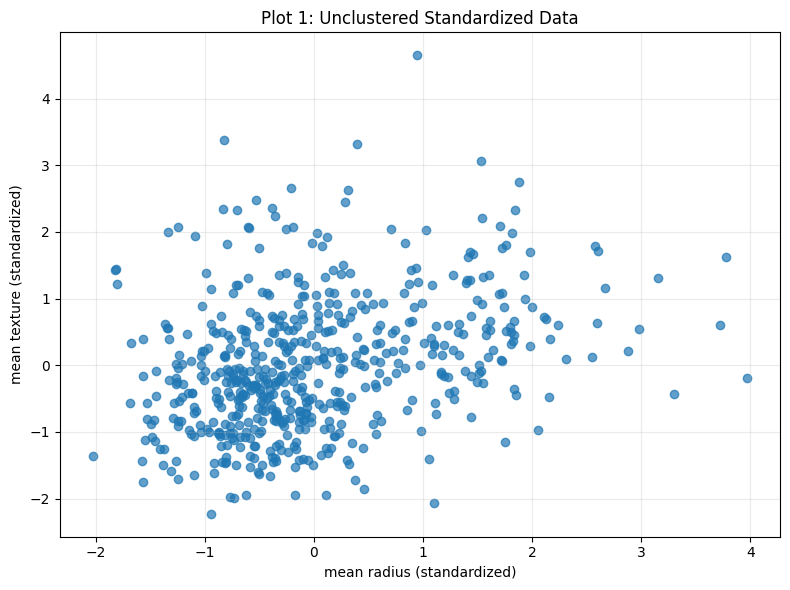

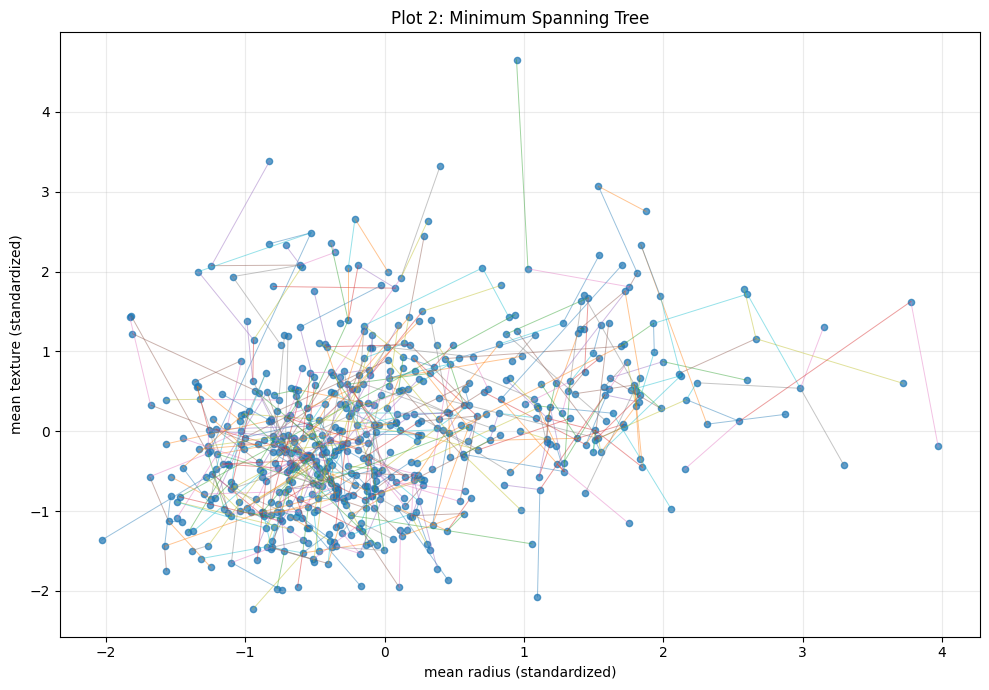

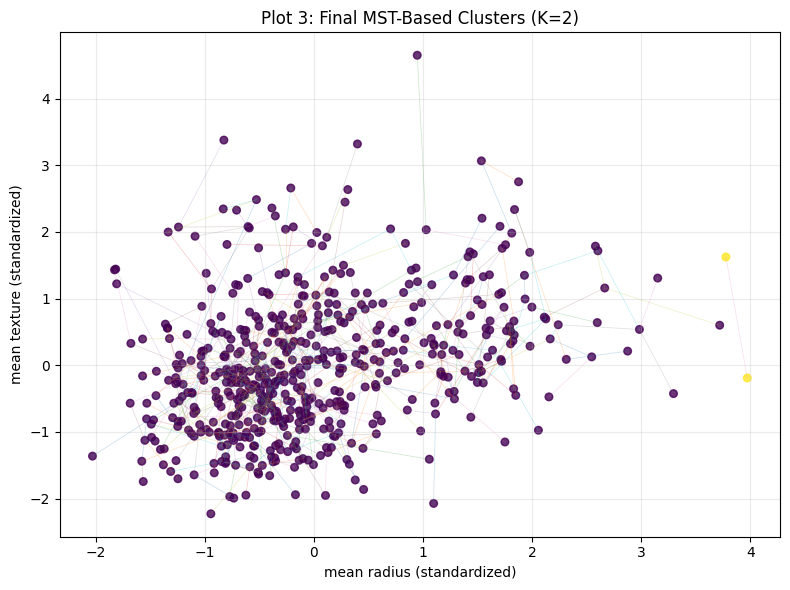

In [8]:
# Task 8: Visualize MST and Graph-Based Clusters

# Select two representative features for 2D visualization.
feature_x = "mean radius"
feature_y = "mean texture"

x_idx = feature_columns.index(feature_x)
y_idx = feature_columns.index(feature_y)

x_values = X_scaled[:, x_idx]
y_values = X_scaled[:, y_idx]

# Plot 1: Unclustered standardized data
plt.figure(figsize=(8, 6))
plt.scatter(x_values, y_values, alpha=0.7)
plt.xlabel(f"{feature_x} (standardized)")
plt.ylabel(f"{feature_y} (standardized)")
plt.title("Plot 1: Unclustered Standardized Data")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 2: MST overlaid on the standardized 2D data
plt.figure(figsize=(10, 7))
plt.scatter(x_values, y_values, s=20, alpha=0.7)

for u, v, data in MST.edges(data=True):
    plt.plot(
        [x_values[u], x_values[v]],
        [y_values[u], y_values[v]],
        linewidth=0.7,
        alpha=0.45
    )

plt.xlabel(f"{feature_x} (standardized)")
plt.ylabel(f"{feature_y} (standardized)")
plt.title("Plot 2: Minimum Spanning Tree")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 3: Final clusters after cutting the largest MST edge
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    x_values,
    y_values,
    c=cluster_labels,
    s=30,
    alpha=0.8
)

# Draw the remaining MST edges
for u, v, data in MST_cluster.edges(data=True):
    plt.plot(
        [x_values[u], x_values[v]],
        [y_values[u], y_values[v]],
        linewidth=0.5,
        alpha=0.25
    )

plt.xlabel(f"{feature_x} (standardized)")
plt.ylabel(f"{feature_y} (standardized)")
plt.title("Plot 3: Final MST-Based Clusters (K=2)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.